
# Supermarket Sales Prediction — Beginner Project (Pandas + Matplotlib + ML)

**Purpose:** Learn how to clean, explore, visualize, and build a prediction model (regression) for supermarket sales data using Python.

**What this notebook contains**
- Data loading instructions 
- Exploratory Data Analysis (EDA)
- Preprocessing (handling missing values, feature engineering)
- Visualizations with Matplotlib / Seaborn
- Model building: Linear Regression and RandomForestRegressor
- Evaluation metrics and plots
- Saving trained model to `supermarket_model.pkl`

**How to use**
1. Install required packages:
2. Install required package " 
```
pip install pandas numpy matplotlib seaborn scikit-learn joblib
```
3. Run the notebook cells top-to-bottom.


In [1]:
# Imports and load data
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

pd.set_option('display.max_columns', 200)
DATA_PATH = 'supermarket_sales.csv'
if not os.path.exists(DATA_PATH):
    print('Warning: supermarket_sales.csv not found in current folder. Please provide the dataset.')
else:
    df = pd.read_csv(DATA_PATH)
    print('Loaded data with shape:', df.shape)
    display(df.head())


Loaded data with shape: (1000, 17)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
# Quick EDA
if 'df' in globals():
    print('Columns:', df.columns.tolist())
    print('\nNull values per column:')
    display(df.isnull().sum().sort_values(ascending=False).head(20))
    print('\nBasic stats for numeric columns:')
    display(df.describe())
else:
    print('Data not loaded.')


Columns: ['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date', 'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income', 'Rating']

Null values per column:


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64


Basic stats for numeric columns:


,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [3]:
# Basic cleaning & feature engineering
if 'df' in globals():
    df_clean = df.copy()
    # Example: convert InvoiceDate or Date column if present
    for date_col in ['Date','InvoiceDate','Date of Purchase','Time']:
        if date_col in df_clean.columns:
            try:
                df_clean[date_col] = pd.to_datetime(df_clean[date_col])
            except:
                pass
    # Example feature: Total price if not present (Quantity * UnitPrice or Total)
    if 'Total' not in df_clean.columns:
        if 'Quantity' in df_clean.columns and 'Unit price' in df_clean.columns:
            df_clean['Total'] = df_clean['Quantity'] * df_clean['Unit price']
        elif 'Quantity' in df_clean.columns and 'Price' in df_clean.columns:
            df_clean['Total'] = df_clean['Quantity'] * df_clean['Price']
    display(df_clean.head())
else:
    print('Data not loaded.')


C:\Users\shive\AppData\Local\Temp\ipykernel_23696\2448041231.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[date_col] = pd.to_datetime(df_clean[date_col])


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Total
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,2025-11-09 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,522.83
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,2025-11-09 10:29:00,Cash,76.40,4.761905,3.8200,9.6,76.40
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,2025-11-09 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,324.31
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,2025-11-09 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,465.76
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,2025-11-09 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,604.17


Using target column: Total


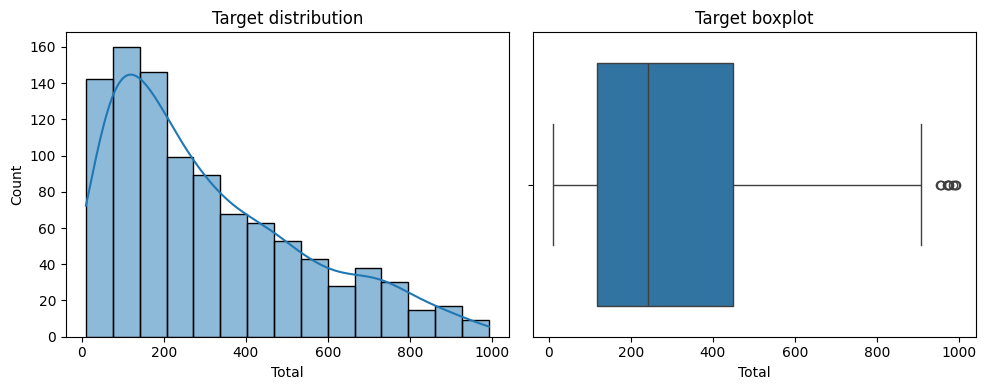

In [4]:
# Select target and show distribution
# We will predict 'Total' (sales amount) if available, otherwise adjust to another numeric target.
if 'df_clean' in globals():
    if 'Total' in df_clean.columns:
        TARGET = 'Total'
    else:
        # choose a numeric column as target (fallback)
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c.lower() not in ['id','index']]
        TARGET = numeric_cols[0] if numeric_cols else None

    print('Using target column:', TARGET)
    if TARGET:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        sns.histplot(df_clean[TARGET].dropna(), kde=True)
        plt.title('Target distribution')
        plt.subplot(1,2,2)
        sns.boxplot(x=df_clean[TARGET].dropna())
        plt.title('Target boxplot')
        plt.tight_layout()
else:
    print('Data not loaded.')


In [5]:
# Feature selection (beginner-friendly subset)
if 'df_clean' in globals() and TARGET:
    # pick a simple set of features commonly present in supermarket datasets
    candidate_features = ['City','Customer type','Gender','Product line','Unit price','Quantity','Tax 5%','Date','Time','Branch']
    features = [f for f in candidate_features if f in df_clean.columns]
    print('Using features:', features)
    X = df_clean[features].copy()
    y = df_clean[TARGET].copy()
    # Drop rows with missing target
    mask = y.notnull()
    X = X[mask]; y = y[mask]
else:
    print('Data not loaded or target not found.')


Using features: ['City', 'Customer type', 'Gender', 'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Date', 'Time', 'Branch']


In [6]:
# Train/test split
if 'X' in globals():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
else:
    print('Features not prepared.')


Train shape: (800, 10) Test shape: (200, 10)


In [7]:
# Build preprocessing pipelines
if 'X_train' in globals():
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    print('Numeric cols:', num_cols)
    print('Categorical cols:', cat_cols)

    numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')), ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
    preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_cols), ('cat', categorical_transformer, cat_cols)])
else:
    print('Train/test split not done.')


Numeric cols: ['Unit price', 'Quantity', 'Tax 5%']
Categorical cols: ['City', 'Customer type', 'Gender', 'Product line', 'Branch']


In [8]:
# Linear Regression baseline
if 'X_train' in globals():
    lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
    lr_pipeline.fit(X_train, y_train)
    y_pred_lr = lr_pipeline.predict(X_test)
    def regression_metrics(y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        return {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print('Linear Regression metrics:'); display(regression_metrics(y_test, y_pred_lr))
else:
    print('Train/test split not done.')


Linear Regression metrics:


{'MAE': 2.0585311233389803e-13,
 'RMSE': np.float64(2.5335995829202117e-13),
 'R2': 1.0}

In [9]:
# Random Forest baseline
if 'X_train' in globals():
    rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    rf_pipeline.fit(X_train, y_train)
    y_pred_rf = rf_pipeline.predict(X_test)
    print('Random Forest metrics:'); display(regression_metrics(y_test, y_pred_rf))
else:
    print('Train/test split not done.')


Random Forest metrics:


{'MAE': 0.7265410000000384,
 'RMSE': np.float64(1.2093614696194355),
 'R2': 0.9999752153136167}

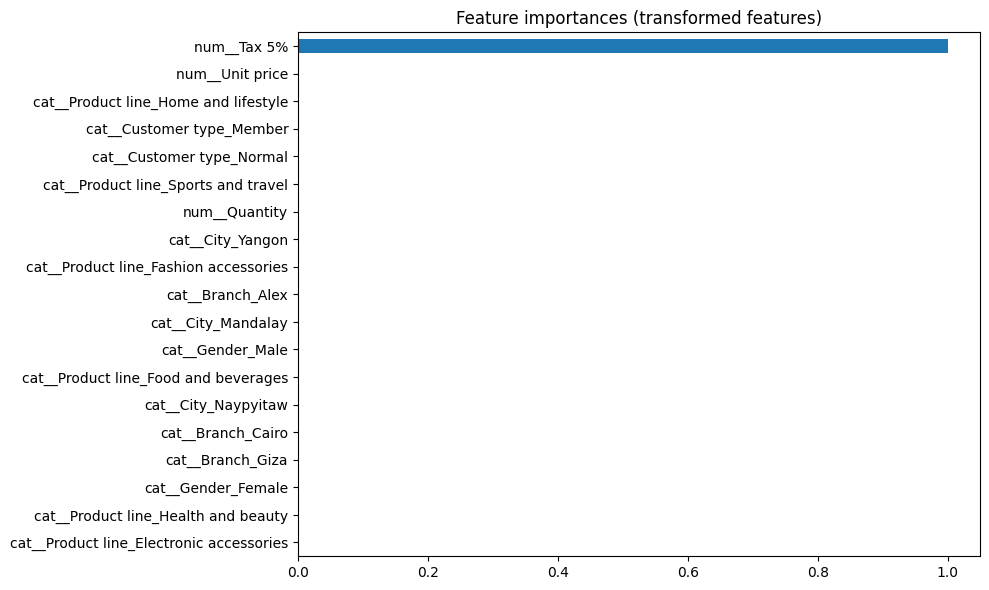

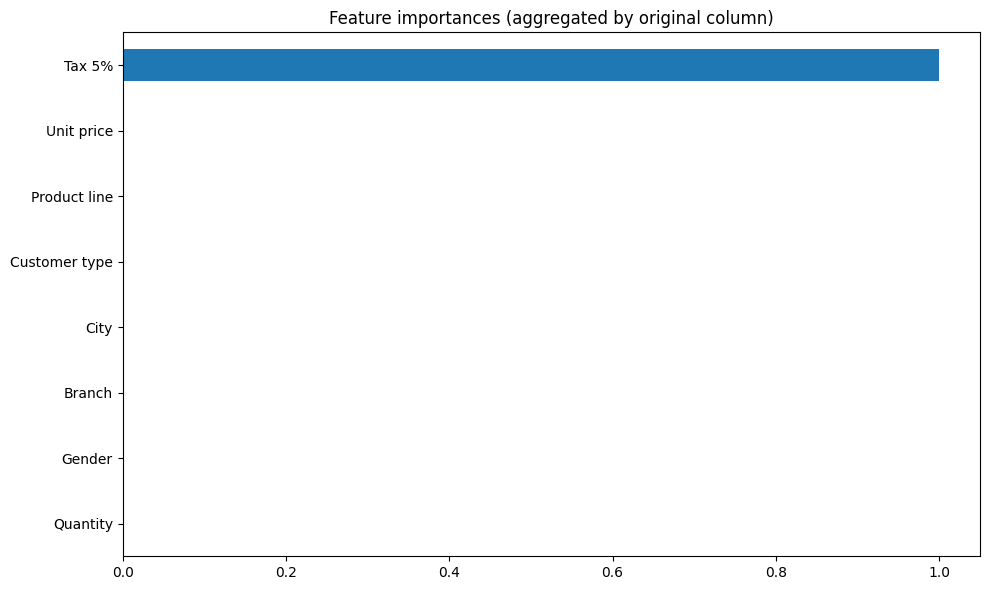

In [10]:

# --- Robust feature importance extraction and plotting (corrected) ---
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure pipeline is present and fitted
if 'rf_pipeline' in globals() and hasattr(rf_pipeline, 'named_steps'):
    preprocessor = rf_pipeline.named_steps.get('preprocessor', None)
    reg = rf_pipeline.named_steps.get('regressor', None)
    if preprocessor is None or reg is None:
        print("Pipeline does not contain 'preprocessor' or 'regressor' named steps.")
    else:
        importances = reg.feature_importances_
        feat_names = []
        orig_map = []

        # Try to get transformed feature names using modern API
        try:
            feat_names = list(preprocessor.get_feature_names_out())
            for name in feat_names:
                parts = re.split(r'__|_', name)
                mapped = None
                for p in parts:
                    if 'X_train' in globals() and p in getattr(X_train, 'columns', []):
                        mapped = p
                        break
                orig_map.append(mapped if mapped is not None else name)
        except Exception:
            # Fallback: iterate through transformers_
            try:
                for name, transformer, cols in preprocessor.transformers_:
                    if name == 'remainder' and transformer == 'drop':
                        continue
                    final_trans = transformer
                    if hasattr(transformer, 'named_steps'):
                        final_trans = transformer.named_steps[list(transformer.named_steps)[-1]]
                    try:
                        out_names = list(final_trans.get_feature_names_out(cols))
                        feat_names.extend(out_names)
                        for out in out_names:
                            found = None
                            for c in cols:
                                if str(out).startswith(str(c)):
                                    found = c
                                    break
                            orig_map.append(found if found else "|".join(cols))
                    except Exception:
                        feat_names.extend(list(cols))
                        orig_map.extend(list(cols))
            except Exception as e:
                print("Failed to extract feature names:", e)
                feat_names = [f"f{i}" for i in range(len(importances))]
                orig_map = list(feat_names)

        # Fix any mismatched lengths
        if len(feat_names) != len(importances):
            print(f"Warning: feature name length {len(feat_names)} != importances {len(importances)}.")
            feat_names = [f"f_{i}" for i in range(len(importances))]
            orig_map = list(feat_names)

        # Plot transformed feature importances
        feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)
        plt.figure(figsize=(10,6))
        feat_imp.head(30).plot(kind='barh')
        plt.gca().invert_yaxis()
        plt.title('Feature importances (transformed features)')
        plt.tight_layout()
        plt.show()

        # Aggregate one-hot encoded features back to original columns
        agg = {}
        for orig, val in zip(orig_map, importances):
            agg[orig] = agg.get(orig, 0.0) + float(val)

        agg_series = pd.Series(agg).sort_values(ascending=False)
        plt.figure(figsize=(10,6))
        agg_series.head(30).plot(kind='barh')
        plt.gca().invert_yaxis()
        plt.title('Feature importances (aggregated by original column)')
        plt.tight_layout()
        plt.show()
else:
    print("rf_pipeline not found — fit your pipeline first (example: rf_pipeline.fit(X_train, y_train))")


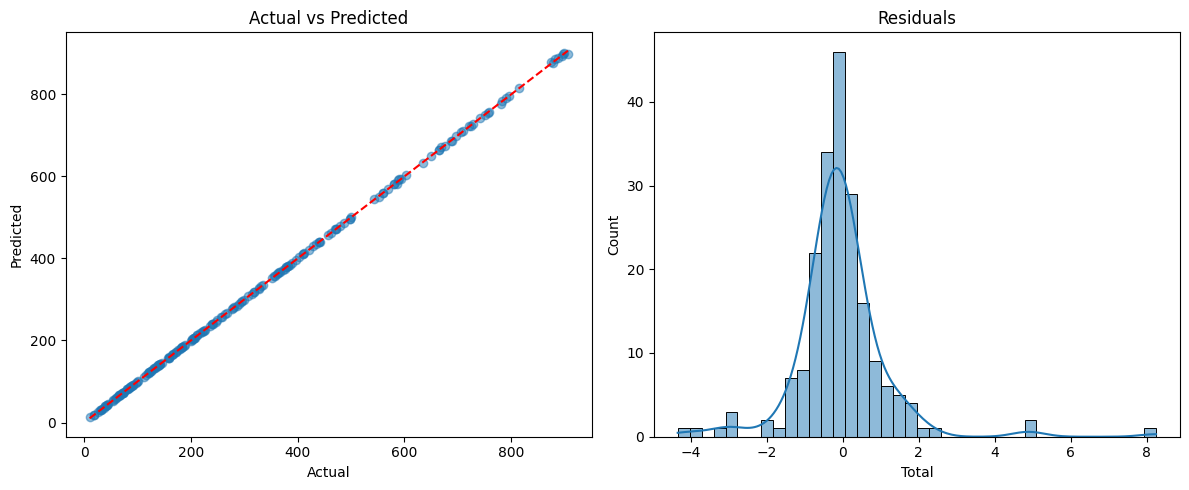

In [11]:
# Residuals and Actual vs Predicted
if 'rf_pipeline' in globals():
    pred = rf_pipeline.predict(X_test)
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(y_test, pred, alpha=0.5); plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--'); plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
    plt.subplot(1,2,2)
    sns.histplot(y_test - pred, bins=40, kde=True); plt.title('Residuals'); plt.tight_layout(); plt.show()
else:
    print('RandomForest model not found.')


In [12]:
# Save trained model
if 'rf_pipeline' in globals():
    joblib.dump(rf_pipeline, 'supermarket_model.pkl')
    print('Saved model to supermarket_model.pkl')
else:
    print('No trained model to save.')


Saved model to supermarket_model.pkl


In [13]:
# Handover summary and next steps
print('This notebook provides a complete pipeline for building a regression model on supermarket sales data.')

This notebook provides a complete pipeline for building a regression model on supermarket sales data.
